In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from MLP import MLP
from Gradcheck import GradientsChecker,check_grads
from Optimizer import Adam,RMSProp,SGD,AdamW
from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_csv('clean.csv')

In [3]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1.0
1,1,1,1,38.0,1,0,71.2833,2.0
2,1,3,1,26.0,0,0,7.9250,1.0
3,1,1,1,35.0,1,0,53.1000,1.0
4,0,3,0,35.0,0,0,8.0500,1.0


In [4]:
x=data.drop('Survived',axis=1)
y=data['Survived']

In [5]:
y=y.to_numpy().reshape(-1,1)

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
model=MLP(7,10,1)
optim=Adam(model)

In [10]:
print("======LAUNCHING GRADEINTS CHECCKING========")
train_losses=[]
diff=GradientsChecker.check(model,x_train,y_train)
print(f"Relative Difference is :{diff}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=model.forward(x_train)
    loss=model.compute_loss(y_pred,y_train)
    train_losses.append(loss)
    model.backward(y_train)
    optim.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")

======LAUNCHING GRADEINTS CHECCKING========
Relative Difference is :2.6616392026547522e-08
succes :Every thing is correct


How many epochs you want to train your model : 1000


epoch :0   | Loss :0.6038521432729701
epoch :100   | Loss :0.5947140061308352
epoch :200   | Loss :0.5855461477462617
epoch :300   | Loss :0.5777606899216209
epoch :400   | Loss :0.5685522807853103
epoch :500   | Loss :0.5561641773679431
epoch :600   | Loss :0.5302527552286715
epoch :700   | Loss :0.49452265373818477
epoch :800   | Loss :0.4782025117813442
epoch :900   | Loss :0.4628599257264608


In [11]:
test_losses=[]
for epoch in range(len(x_test)):
    pred=model.forward(x_test)
    test_loss=model.compute_loss(pred,y_test)
    test_losses.append(test_loss)
    prediction=np.mean(pred>=0.5).astype(int)
    acc=np.mean(prediction==y_test)

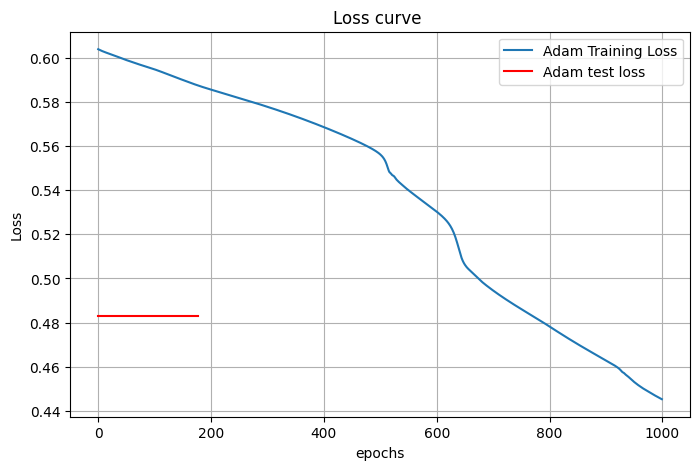

In [13]:
plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Adam Training Loss")
plt.plot(test_losses,label="Adam test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()

In [14]:
model2=MLP(7,10,1)
optimizer=AdamW(model2)

In [15]:
print("======LAUNCHING GRADEINTS CHECCKING========")
train_losses2=[]
diff2=GradientsChecker.check(model2,x_train,y_train)
print(f"Relative Difference is :{diff2}")
if diff<1e-7:
    print("succes :Every thing is correct")
elif diff<1e-4:
    print("Wrong :Minor precision")
else:
    print("Fianal Error : Check your implementation line by line")
epochs=int(input("How many epochs you want to train your model :"))
for epoch in range(epochs):
    y_pred=model2.forward(x_train)
    loss2=model2.compute_loss(y_pred,y_train)
    train_losses2.append(loss2)
    model2.backward(y_train)
    optimizer.step()

    if epoch %100==0:
        print(f"epoch :{epoch}   | Loss :{loss}")

======LAUNCHING GRADEINTS CHECCKING========
Relative Difference is :2.6419300434063765e-09
succes :Every thing is correct


How many epochs you want to train your model : 2000


epoch :0   | Loss :0.4452846240016033
epoch :100   | Loss :0.4452846240016033
epoch :200   | Loss :0.4452846240016033
epoch :300   | Loss :0.4452846240016033
epoch :400   | Loss :0.4452846240016033
epoch :500   | Loss :0.4452846240016033
epoch :600   | Loss :0.4452846240016033
epoch :700   | Loss :0.4452846240016033
epoch :800   | Loss :0.4452846240016033
epoch :900   | Loss :0.4452846240016033
epoch :1000   | Loss :0.4452846240016033
epoch :1100   | Loss :0.4452846240016033
epoch :1200   | Loss :0.4452846240016033
epoch :1300   | Loss :0.4452846240016033
epoch :1400   | Loss :0.4452846240016033
epoch :1500   | Loss :0.4452846240016033
epoch :1600   | Loss :0.4452846240016033
epoch :1700   | Loss :0.4452846240016033
epoch :1800   | Loss :0.4452846240016033
epoch :1900   | Loss :0.4452846240016033


In [16]:
test_losses2=[]
for epoch in range(len(x_test)):
    pred2=model2.forward(x_test)
    test_loss2=model2.compute_loss(pred2,y_test)
    test_losses2.append(test_loss2)
    prediction2=np.mean(pred>=0.5).astype(int)
    acc2=np.mean(prediction2==y_test)

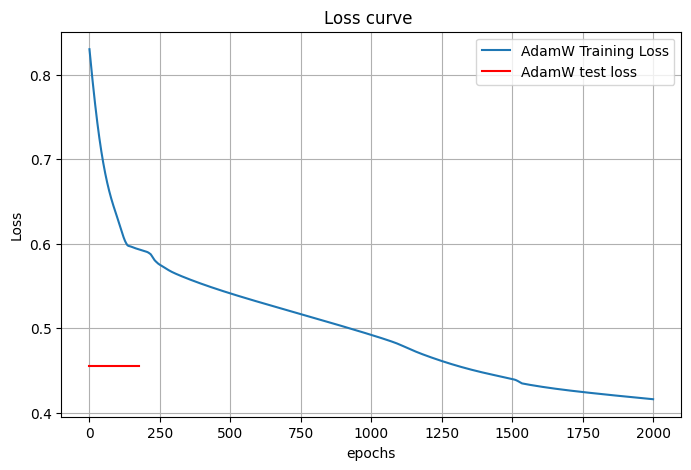

In [17]:
plt.figure(figsize=(8,5))
plt.plot(train_losses2,label="AdamW Training Loss")
plt.plot(test_losses2,label="AdamW test loss",c='r')
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Loss curve ")
plt.grid(True)
plt.legend()
plt.show()